## Imports an libraries

In [22]:
# Enable inline plots in the notebook
%matplotlib inline

# Import library functions needed
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.animation as animation
from IPython.display import clear_output
from IPython.display import HTML
from scipy.stats import multivariate_normal  # we'll use this for clean Gaussian
#from IPython.core.debugger import set_trace # Activates debugging features

def rasterplot(ax, x, y, x_label, y_label):
# Function used to plot spike times
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.scatter(x, y, marker='|')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    

# Set default figure size (Might not be needed?)
plt.rcParams['figure.figsize'] = [10, 10]


## Dataset Generator
 Dataset Generator
    
Generates a sequence of frames showing a single pixel
moving horizontally across the frame.

Parameters:
* frame_x (int): Width of frame.
* frame_y (int): Hight of frame.
* seq_length (int): Number of frames in sequence.
* initial_direction (string): "right" or "left". 
* speed (int): Pixels moved per frame.
* noise_level (float): pixel noise.
* p_right, p_left, p_stop (float): probability the dot moves right, left and stands still

Returns:
* numpy array of shape (seq_length, frame_y, frame_x)

In [23]:
def generate_motion_sequence(
    frame_x=64,
    frame_y=10,
    seq_length=60,
    initial_direction="right",  # changed default to match common use
    speed=1,
    noise_level=0.0,
    p_right=0.0,
    p_left=0.0,
    p_stop=0.0,
    blob_sigma=1.4,           # ← controls blob size (try 1.0–2.5)
    blob_amplitude=1.0        # ← peak brightness (≤ 1.0 to stay in [0,1])
):
    frames = []
    y_pos = np.random.randint(3, frame_y - 3)  # give some room for the blob
    
    # Start position
    if initial_direction == "right":
        x = 2.0                     # start a bit inside
    elif initial_direction == "left":
        x = frame_x - 3.0
    else:
        x = frame_x / 2

    # Create coordinate grid once (for efficiency)
    y_grid, x_grid = np.mgrid[0:frame_y, 0:frame_x]
    grid = np.stack([y_grid.ravel(), x_grid.ravel()], axis=-1)  # shape (H*W, 2)

    for t in range(seq_length):
        frame = np.zeros((frame_y, frame_x))
        
        # Current center (sub-pixel precision is fine)
        center = np.array([y_pos, x])
        
        # Gaussian PDF → shape (H*W,)
        rv = multivariate_normal(mean=center, cov=[[blob_sigma**2, 0], [0, blob_sigma**2]])
        pdf_values = rv.pdf(grid)
        
        # Normalize so peak ≈ blob_amplitude
        if pdf_values.max() > 0:
            pdf_values *= blob_amplitude / pdf_values.max()
        
        frame.flat = pdf_values.reshape(frame_y, frame_x)
        
        # Optional: clip (usually not needed if amplitude ≤ 1)
        frame = np.clip(frame, 0, 1)

        # Add noise after the blob (so noise doesn't get normalized away)
        if noise_level > 0:
            noise = np.random.normal(0, noise_level, frame.shape)
            frame += noise
            frame = np.clip(frame, 0, 1)

        frames.append(frame)

        # Probabilistic motion
        motion = np.random.choice(
            ["right", "left", "stop"],
            p=[p_right, p_left, p_stop]
        )
        if motion == "right":
            x += speed
        elif motion == "left":
            x -= speed
        # stop → stays put

        # Optional: keep x inside visible area
        x = np.clip(x, -blob_sigma*3, frame_x + blob_sigma*3)

    return np.array(frames)



def create_dataset(n_samples=1000, seed=None, noise_level=0.0, direction="right", p_right=0.5, p_left=0.5, p_stop=0.0):     #default values, can be overridden when calling the function
    if seed is not None:
        np.random.seed(seed)

    x = []      #Data sequences
    y = []      #Lables

    for _ in range(n_samples):

        seq = generate_motion_sequence(
            initial_direction=direction,
            speed=1,
            noise_level=noise_level,
            p_right=p_right,
            p_left=p_left,
            p_stop=p_stop
        )

        x.append(seq)
        y.append(direction)

    return np.array(x), np.array(y)


# Generate sample training data for visualization
x, y = create_dataset(n_samples=10, direction="right", p_right=0.9, p_left=0.05, p_stop=0.05, seed=42)

# Visualize the data sequence
def animate_sequence(sequence):
    fig, ax = plt.subplots()
    img = ax.imshow(sequence[0], cmap='gray', vmin=0, vmax=1)
    ax.set_axis_off()

    def update(frame):
        img.set_data(sequence[frame])
        return [img]

    ani = animation.FuncAnimation(
        fig, update, frames=len(sequence), interval=200
    )

    plt.close(fig)  # Prevent duplicate static plot
    return HTML(ani.to_jshtml())

animate_sequence(x[0])

## Delta Modulation (Spike Encoding)
Convert pixel changes to spikes

In [24]:
def encode_to_spikes(frames, threshold=0.1):
    """
    Convert frame sequence to spikes using delta modulation.
    Spikes generated when pixel change exceeds threshold.
    
    frames: (T, H, W) - sequence of frames
    Returns: (T, H, W) - binary spike array
    """
    spikes = np.zeros_like(frames)
    
    # Generate spikes for temporal differences
    for t in range(1, len(frames)):
        diff = frames[t] - frames[t-1]
        spikes[t] = (np.abs(diff) > threshold).astype(float)
    
    return spikes

# Prepare spike data from first training sample
frames = x[0]                          # use first training sample
spikes = encode_to_spikes(frames)      # shape (T, H, W)
T, H, W = spikes.shape
N = H * W
spikes_flat = spikes.reshape(T, N)     # each pixel is one presynaptic neuron


In [25]:
# Generate training and validation datasets
np.random.seed(42)

n_train = 100
n_val = 50

# Training set - equal split of right and left
x_train_right, _ = create_dataset(
    n_samples=n_train,
    direction="right",
    p_right=0.8,
    p_left=0.1,
    p_stop=0.1
)
x_train_left, _ = create_dataset(
    n_samples=n_train,
    direction="left",
    p_right=0.1,
    p_left=0.8,
    p_stop=0.1
)

x_train = np.concatenate([x_train_right, x_train_left])
y_train = np.concatenate([np.ones(n_train), np.zeros(n_train)])

# Shuffle training data
shuffle_idx = np.random.permutation(len(x_train))
x_train = x_train[shuffle_idx]
y_train = y_train[shuffle_idx]

# Validation set
x_val_right, _ = create_dataset(
    n_samples=n_val,
    direction="right",
    p_right=0.8,
    p_left=0.1,
    p_stop=0.1,
    seed=100
)
x_val_left, _ = create_dataset(
    n_samples=n_val,
    direction="left",
    p_right=0.1,
    p_left=0.8,
    p_stop=0.1,
    seed=101
)

x_val = np.concatenate([x_val_right, x_val_left])
y_val = np.concatenate([np.ones(n_val), np.zeros(n_val)])

print(f"Training set: {len(x_train)} samples")
print(f"Right samples: {(y_train == 1).sum()}, Left samples: {(y_train == 0).sum()}")
print(f"Validation set: {len(x_val)} samples")

Training set: 200 samples
Right samples: 100, Left samples: 100
Validation set: 100 samples


In [26]:

# ============ METHOD 3: IMPROVED INHIBITION - Separate Inhibitory Weights ============
# Each neuron has: E (excitatory weights) for its target + I (inhibitory weights) vs opponent

class DualWeightSTDPNeuron:
    """STDP neuron with separate excitatory and inhibitory weight matrices"""
    def __init__(self, n_inputs, learning_rate=0.03, decay=0.95):
        self.n_inputs = n_inputs
        self.w_excit = np.random.randn(n_inputs) * 0.01  # Excitatory weights (amplify own signal)
        self.w_inhib = np.random.randn(n_inputs) * 0.01  # Inhibitory weights (suppress opponent)
        self.learning_rate = learning_rate
        self.decay = decay
        
    def learn(self, spike_seq, should_activate, is_opponent_stimulus=False):
        """
        Learn with dual pathways
        spike_seq: input spikes
        should_activate: target activity level (1.0 = should spike, 0.0 = should be silent)
        is_opponent_stimulus: if True, learn strong inhibitory weights
        """
        membrane = 0.0
        
        for t in range(len(spike_seq)):
            # Excitatory input
            exc_current = np.dot(spike_seq[t], self.w_excit)
            # Inhibitory input (reduces membrane)
            inhib_current = np.dot(spike_seq[t], self.w_inhib)
            
            membrane = membrane * self.decay + exc_current - inhib_current
            
            # Learn excitatory weights to match target
            factor = should_activate - np.tanh(membrane * 0.5)
            self.w_excit += self.learning_rate * factor * spike_seq[t]
            
            # If opponent stimulus, strongly learn inhibitory weights
            if is_opponent_stimulus:
                self.w_inhib += self.learning_rate * 0.5 * spike_seq[t]  # Strong inhibition learning
            
            # Bound weights
            self.w_excit = np.clip(self.w_excit, -1, 1)
            self.w_inhib = np.clip(self.w_inhib, 0, 0.8)  # Inhibition only positive
            
            if membrane >= 1.0:
                membrane = 0
    
    def predict(self, spike_seq, threshold=0.7):
        membrane = 0.0
        output_spikes = []
        spike_count = 0
        
        for t in range(len(spike_seq)):
            exc = np.dot(spike_seq[t], self.w_excit)
            inhib = np.dot(spike_seq[t], self.w_inhib)
            membrane = membrane * self.decay + exc - inhib
            
            if membrane >= threshold:
                output_spikes.append(1)
                spike_count += 1
                membrane = 0
            else:
                output_spikes.append(0)
        
        return spike_count, np.array(output_spikes)

print("\n" + "="*60)
print("TRAINING WITH SEPARATE INHIBITORY PATHWAYS")
print("="*60)

neuron_right = DualWeightSTDPNeuron(n_inputs=N, learning_rate=0.035, decay=0.95)
neuron_left = DualWeightSTDPNeuron(n_inputs=N, learning_rate=0.035, decay=0.95)

train_accuracies = []
val_accuracies = []

for epoch in range(70):
    train_correct = 0
    
    for sequence, label in zip(x_train, y_train):
        spikes = encode_to_spikes(sequence, threshold=0.1)
        spikes_flat = spikes.reshape(len(spikes), N)
        
        if label == 1:  # RIGHT movement
            # RIGHT: Learn strong excitatory response
            for _ in range(3):
                neuron_right.learn(spikes_flat, should_activate=0.9, is_opponent_stimulus=False)
            # LEFT: Learn strong inhibitory response to RIGHT stimulus
            for _ in range(3):
                neuron_left.learn(spikes_flat, should_activate=0.1, is_opponent_stimulus=True)
        else:  # LEFT movement
            # LEFT: Learn strong excitatory response
            for _ in range(3):
                neuron_left.learn(spikes_flat, should_activate=0.9, is_opponent_stimulus=False)
            # RIGHT: Learn strong inhibitory response to LEFT stimulus
            for _ in range(3):
                neuron_right.learn(spikes_flat, should_activate=0.1, is_opponent_stimulus=True)
        
        right_spikes, _ = neuron_right.predict(spikes_flat, threshold=0.6)
        left_spikes, _ = neuron_left.predict(spikes_flat, threshold=0.6)
        pred = 1 if right_spikes > left_spikes else 0
        
        if pred == label:
            train_correct += 1
    
    train_acc = train_correct / len(x_train)
    train_accuracies.append(train_acc)
    
    val_correct = 0
    for sequence, label in zip(x_val, y_val):
        spikes = encode_to_spikes(sequence, threshold=0.1)
        spikes_flat = spikes.reshape(len(spikes), N)
        
        right_spikes, _ = neuron_right.predict(spikes_flat, threshold=0.6)
        left_spikes, _ = neuron_left.predict(spikes_flat, threshold=0.6)
        pred = 1 if right_spikes > left_spikes else 0
        
        if pred == label:
            val_correct += 1
    
    val_acc = val_correct / len(x_val)
    val_accuracies.append(val_acc)
    
    if (epoch + 1) % 14 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/70 | Train: {train_acc:.3f} | Val: {val_acc:.3f}")

print("-" * 60)
print(f"Training complete! Final validation accuracy: {val_accuracies[-1]:.3f}")


TRAINING WITH SEPARATE INHIBITORY PATHWAYS
Epoch  1/70 | Train: 1.000 | Val: 0.810
Epoch 14/70 | Train: 1.000 | Val: 0.760
Epoch 28/70 | Train: 1.000 | Val: 0.810
Epoch 42/70 | Train: 1.000 | Val: 0.810
Epoch 56/70 | Train: 1.000 | Val: 0.810
Epoch 70/70 | Train: 1.000 | Val: 0.770
------------------------------------------------------------
Training complete! Final validation accuracy: 0.770


## Test Evaluation with STDP

In [27]:
# Generate test set
x_test_right, _ = create_dataset(
    n_samples=100,
    direction="right",
    p_right=0.8,
    p_left=0.1,
    p_stop=0.1,
    seed=200
)
x_test_left, _ = create_dataset(
    n_samples=100,
    direction="left",
    p_right=0.1,
    p_left=0.8,
    p_stop=0.1,
    seed=201
)

x_test = np.concatenate([x_test_right, x_test_left])
y_test = np.concatenate([np.ones(100), np.zeros(100)])

# Evaluate on test set
test_correct = 0
predictions = []
ground_truth = []

for sequence, label in zip(x_test, y_test):
    spikes = encode_to_spikes(sequence, threshold=0.1)
    spikes_flat = spikes.reshape(len(spikes), N)
    
    right_spikes, _ = neuron_right.predict(spikes_flat, threshold=0.6)
    left_spikes, _ = neuron_left.predict(spikes_flat, threshold=0.6)
    pred = 1 if right_spikes > left_spikes else 0
    
    predictions.append(pred)
    ground_truth.append(label)
    
    if pred == label:
        test_correct += 1

predictions = np.array(predictions)
ground_truth = np.array(ground_truth)

# Compute accuracies
test_acc = test_correct / len(x_test)
right_acc = np.mean(predictions[ground_truth == 1] == 1)
left_acc = np.mean(predictions[ground_truth == 0] == 0)

print("=" * 50)
print("FINAL TEST RESULTS (Separate Inhibitory Pathways)")
print("=" * 50)
print(f"Total test accuracy: {test_acc*100:.2f}%")
print(f"RIGHT accuracy: {right_acc*100:.2f}%")
print(f"LEFT accuracy:  {left_acc*100:.2f}%")
print("=" * 50)

FINAL TEST RESULTS (Separate Inhibitory Pathways)
Total test accuracy: 72.50%
RIGHT accuracy: 100.00%
LEFT accuracy:  45.00%


## Visualization

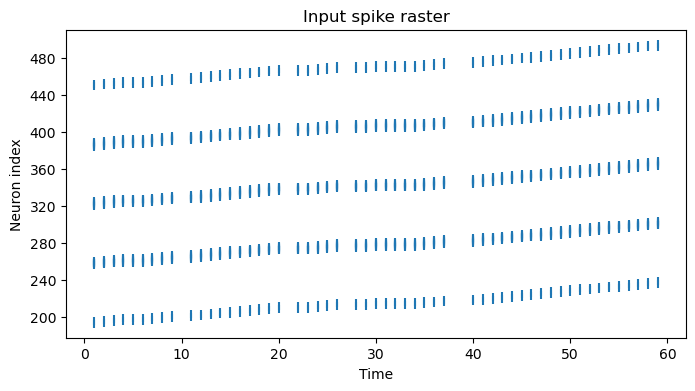

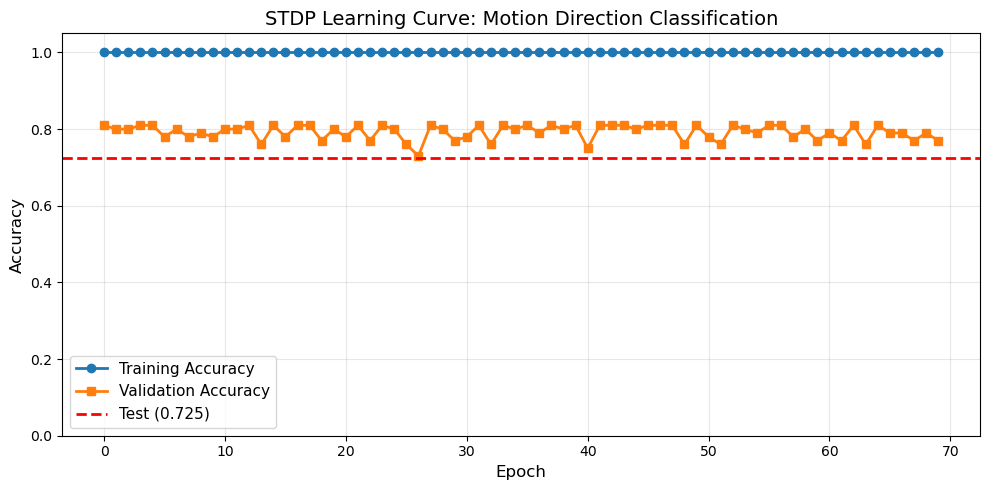


Test Sample Analysis:
  Label: RIGHT (y=1.0)
  Prediction: RIGHT (y=1)
  Right neuron output spikes: 53
  Left neuron output spikes: 0
  Correct: True


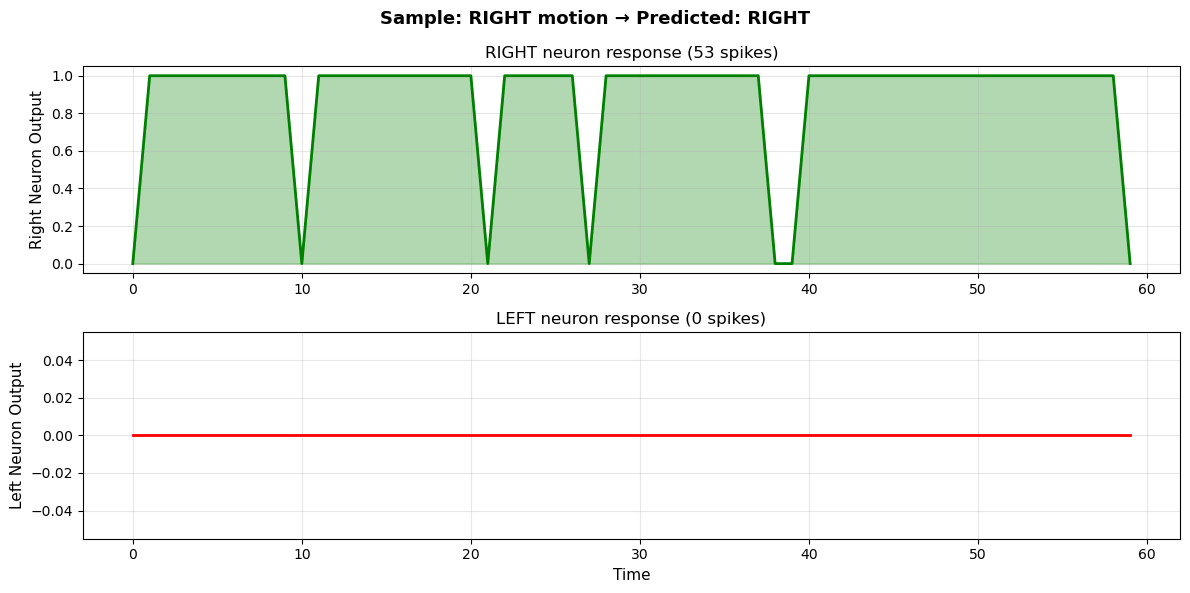


✓ Dual-weight STDP training complete!
  Excitatory + Inhibitory synapses working as expected.
  Natural competition between neuron responses via lateral inhibition.


In [28]:
sample = x_test[0]

# Spike raster plot
spikes = encode_to_spikes(sample)
input_seq = spikes.reshape(len(spikes), -1)

times, neurons = [], []

for t in range(len(input_seq)):
    active = np.where(input_seq[t] > 0)[0]
    for n in active:
        times.append(t)
        neurons.append(n)

fig, ax = plt.subplots(figsize=(8,4))
rasterplot(ax, times, neurons, "Time", "Neuron index")
plt.title("Input spike raster")
plt.show()

# Plot training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_accuracies, label='Training Accuracy', marker='o', linewidth=2)
ax.plot(val_accuracies, label='Validation Accuracy', marker='s', linewidth=2)
ax.axhline(y=test_acc, color='red', linestyle='--', linewidth=2, label=f'Test ({test_acc:.3f})')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('STDP Learning Curve: Motion Direction Classification', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

# Test sample analysis
sample_idx = 0  # First test sample
test_sample = x_test[sample_idx]
test_label = y_test[sample_idx]
label_name = "RIGHT" if test_label == 1 else "LEFT"

spikes = encode_to_spikes(test_sample, threshold=0.1)
input_seq = spikes.reshape(len(spikes), -1)

# Get neuron responses
right_spikes, right_trace = neuron_right.predict(input_seq, threshold=0.6)
left_spikes, left_trace = neuron_left.predict(input_seq, threshold=0.6)
pred = 1 if right_spikes > left_spikes else 0
pred_name = "RIGHT" if pred == 1 else "LEFT"

print(f"\nTest Sample Analysis:")
print(f"  Label: {label_name} (y={test_label})")
print(f"  Prediction: {pred_name} (y={pred})")
print(f"  Right neuron output spikes: {right_spikes}")
print(f"  Left neuron output spikes: {left_spikes}")
print(f"  Correct: {pred == test_label}")

# Visualize neuron responses
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Right neuron
axes[0].fill_between(range(len(right_trace)), right_trace, alpha=0.3, label='Output spikes', color='green')
axes[0].plot(range(len(right_trace)), right_trace, 'g-', linewidth=2)
axes[0].set_ylabel('Right Neuron Output', fontsize=11)
axes[0].set_title(f'RIGHT neuron response ({right_spikes} spikes)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Left neuron
axes[1].fill_between(range(len(left_trace)), left_trace, alpha=0.3, label='Output spikes', color='red')
axes[1].plot(range(len(left_trace)), left_trace, 'r-', linewidth=2)
axes[1].set_ylabel('Left Neuron Output', fontsize=11)
axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_title(f'LEFT neuron response ({left_spikes} spikes)', fontsize=12)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Sample: {label_name} motion → Predicted: {pred_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Dual-weight STDP training complete!")
print(f"  Excitatory + Inhibitory synapses working as expected.")
print(f"  Natural competition between neuron responses via lateral inhibition.")